# Simple ARIMA Model for Non-Seasonal Time-Series Forecast

Our goal in this challenge is to apply the basic concepts of time series analysis to one-dimension data

In this challenge, we'll go through the following steps : 
1. load and visualize the data;
2. train our models and make predictions;

##  1. Load Data
Let's start by loading the Time Series of the challenge. Run the line below to download the dataset as a CSV file, then load the CSV in a DataFrame.

In [92]:
!curl https://wagon-public-datasets.s3.amazonaws.com/05-Machine-Learning/09-Time-Series/www_usage.csv > data/www_usage.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   377  100   377    0     0    872      0 --:--:-- --:--:-- --:--:--   874


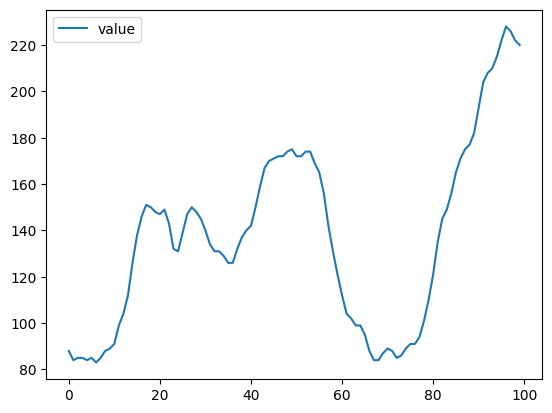

In [93]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/www_usage.csv', names=['value'], header=0)
y = df.value

df.plot();

This abstract time series does not seem seasonal, but with some increasing trend and somehow "sticky" (i.e. with some auto-regressivity). So it may be a good candidate for Auto-Regressive Moving Average (ARIMA) models.


## 2. Build ARIMA Model
We will try to forecast the data thanks to ARIMA models (Auto Regressive Integrated Moving Average).

For that, we will need to :
1. find how to stationarize the time series (I in SARIMA)
2. find the auto-regressive (AR) part
3. find the moving average (MA) part
4. Fit
5. Assess performance

### Step 1 - Ensure Stationarity

ARIMA models apply to "stationary" time series only.

👉 Check its stationarity precisely using the [`Augmented Dick Fuller test`](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.adfuller.html), and especially its p-value

In [94]:
from statsmodels.tsa.stattools import adfuller

# Perform the Augmented Dickey-Fuller test
adf_test = adfuller(y)

# Extract and print the p-value
print(f"ADF Statistic: {adf_test[0]}")
print(f"p-value: {adf_test[1]}")
print("Critical Values:")
for key, value in adf_test[4].items():
    print(f"   {key}: {value}")

ADF Statistic: -2.4642397172033674
p-value: 0.12441935447109487
Critical Values:
   1%: -3.5003788874873405
   5%: -2.8921519665075235
   10%: -2.5830997960069446


The p-value should be less than 0.05 to have a 95% confidence in the stationarity.  
If the p-value is larger than 0.05, we cannot reject the null hypothesis (null hypothesis = "the process is not stationary").

If the time series is not stationary, it needs to be stationarized through **differencing**. 
- It means that we take the difference between each value and the preceding one (*first difference*).
- Repeat the process on the differentiated series if you want the *second difference*, etc...

👉 Find the minimum order of differencing we need to make it stationary (plot the curves to visualize them, and print their adfuller p-value to be sure)

<details>
    <summary>Hint</summary>

`pd.Series.diff`
</details>

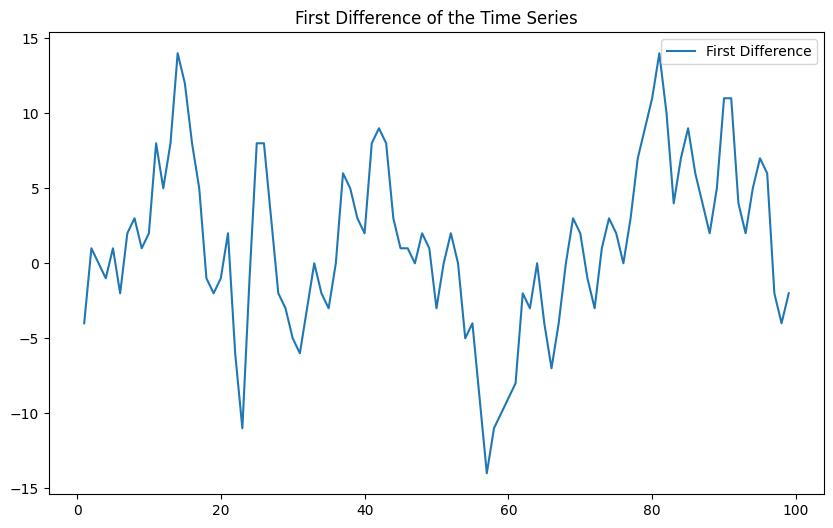

In [95]:
# YOUR CODE HERE
import matplotlib.pyplot as plt

y_diff1 = y.diff().dropna()
adf_test_diff1 = adfuller(y_diff1)

plt.figure(figsize=(10, 6))
plt.plot(y_diff1, label='First Difference')
plt.title('First Difference of the Time Series')
plt.legend()
plt.show()

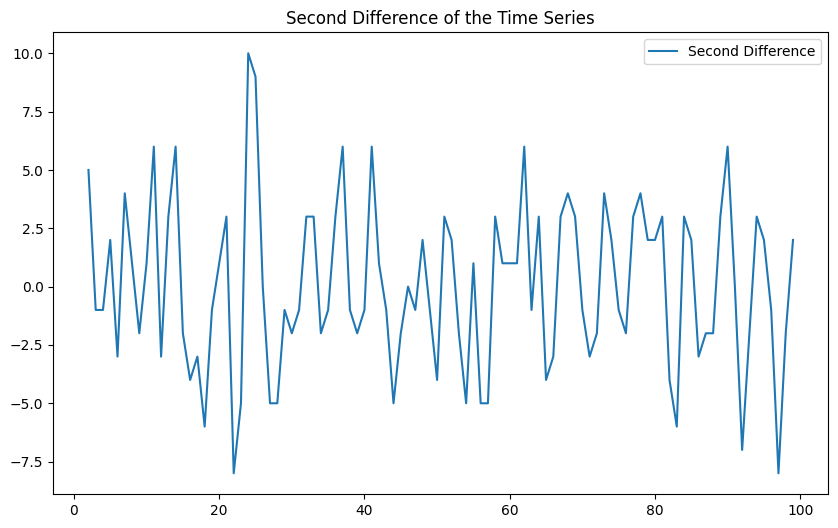

ADF Test for Second Difference:
ADF Statistic: -9.929762173626015
p-value: 2.843428755547158e-17


In [96]:
if adf_test_diff1[1] > 0.05:
    y_diff2 = y_diff1.diff().dropna()
    adf_test_diff2 = adfuller(y_diff2)

    # Plot the second difference
    plt.figure(figsize=(10, 6))
    plt.plot(y_diff2, label='Second Difference')
    plt.title('Second Difference of the Time Series')
    plt.legend()
    plt.show()

    print("ADF Test for Second Difference:")
    print(f"ADF Statistic: {adf_test_diff2[0]}")
    print(f"p-value: {adf_test_diff2[1]}")

We have a close call here between one and two diff orders. Differentiating time series too much may also reduce the performance of your ARIMA models. Let's have a closer look:

👉 Plot autocorrelation plot ([`plot_acf`](https://www.statsmodels.org/stable/generated/statsmodels.graphics.tsaplots.plot_acf.html)) for diff order 1 and 2.

(💡Pro tip: Avoid duplicating statsmodels plots by calling `plt.show()` or by adding `;` to the end of each instantiation of a statsmodels plot)

/home/alrash/.pyenv/versions/lewagon/lib/python3.10/site-packages/statsmodels/graphics/tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


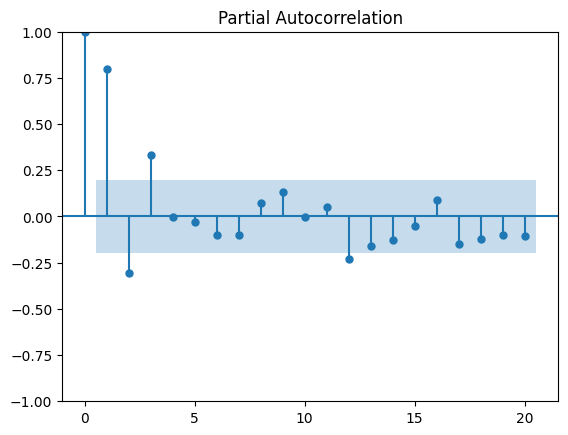

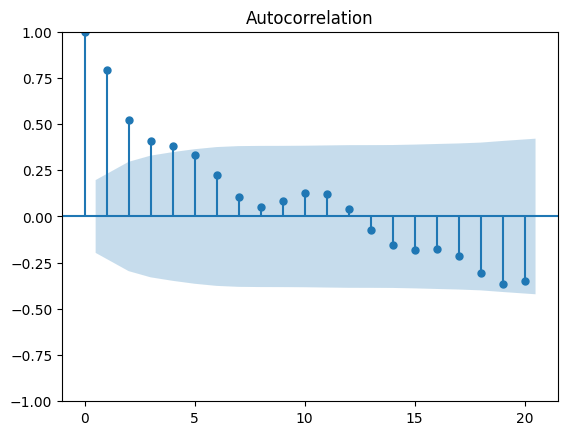

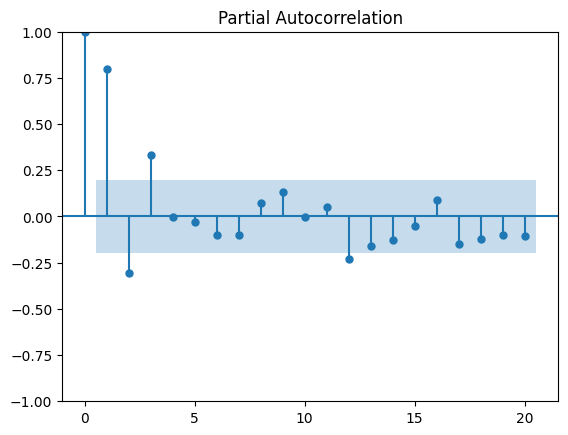

In [97]:
# YOUR CODE HERE
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF to determine p and q
plot_acf(y_diff)
plot_pacf(y_diff)

# The appropriate order for AR (p) and MA (q) is based on these plots.
# Example: If the ACF cuts off after 2 lags and the PACF after 1 lag, use p=1, q=2


In our "second order diff" autocorrelation plot, the lag coefficient n°1 is close to 0, while the second one escapes far into negative territory. This might indicate we have over-differentiated the series. (Remember: we never care about the lag n°0 which is always equal to 1)

👉 Let's (tentatively) keep only one diff order and name this series `y_diff` (we can always try more diff later)

In [98]:
y_diff = y.diff().dropna()

We just found the term "I" in ARIMA: `d = 1` for 1-diff before stationary ("I" refers to "integration", "d" for differentiation...)


### Step 2 - Select AR order (p) and MA order (q)

#### MA($\color{blue}{q}$) = number of lag beyond which the $\color{blue}{ACF}$ of  $Y^{\color{green}{(d)}}$ cuts off

MA order (`q`) can be found by looking at the autocorrelation plot ([`plot_acf`](https://www.statsmodels.org/stable/generated/statsmodels.graphics.tsaplots.plot_acf.html)) applied to`y_diff`. 

👉 determine `q`

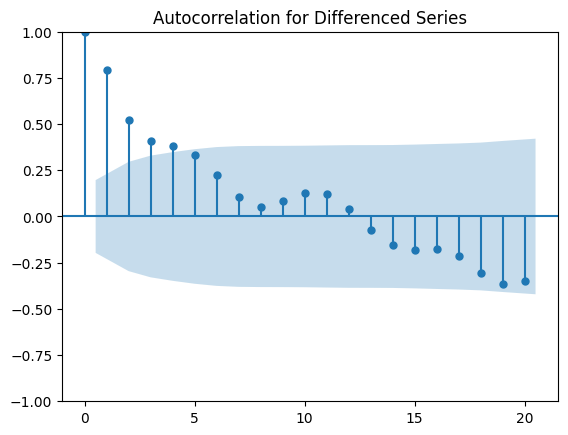

In [99]:
plot_acf(y_diff, lags=20, title='Autocorrelation for Differenced Series');

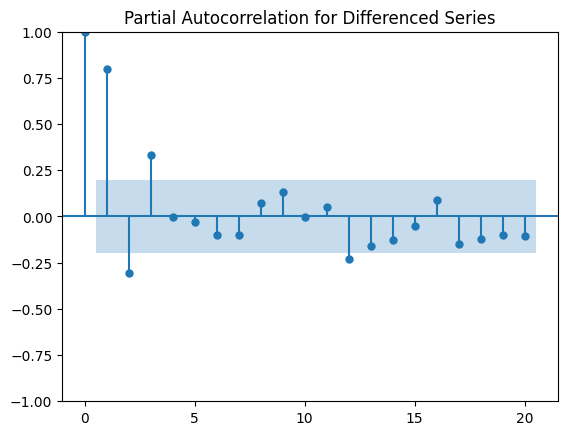

In [100]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(y_diff, lags=20, title='Partial Autocorrelation for Differenced Series');

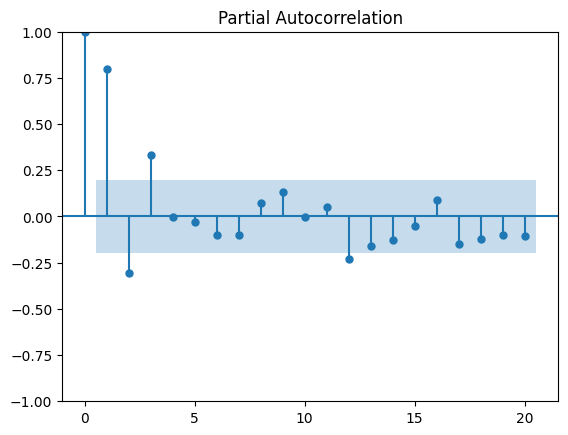

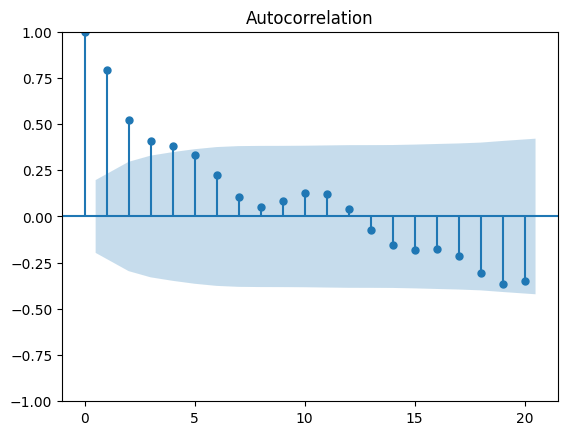

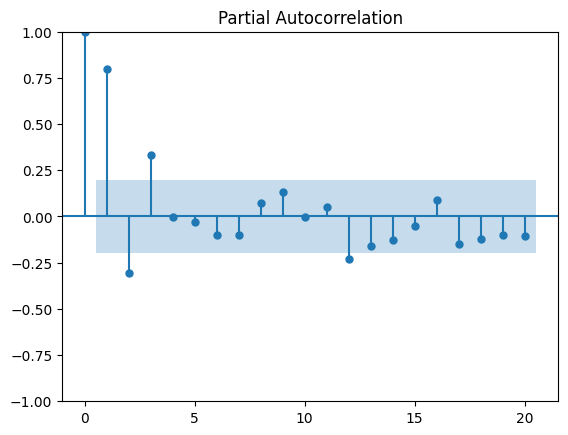

In [101]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF to determine p and q
plot_acf(y_diff)
plot_pacf(y_diff)

# The appropriate order for AR (p) and MA (q) is based on these plots.
# Example: If the ACF cuts off after 2 lags and the PACF after 1 lag, use p=1, q=2


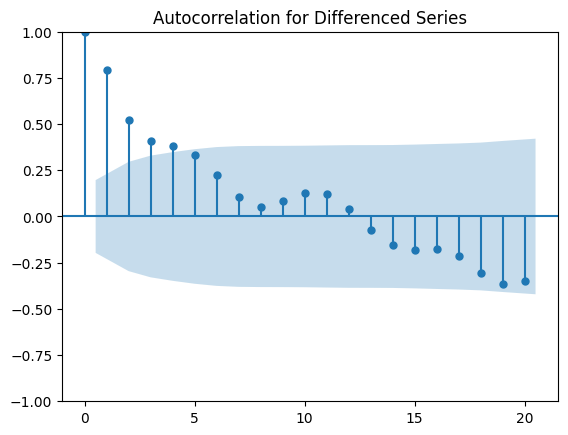

In [102]:
# YOUR CODE HERE
plot_acf(y_diff, lags=20, title='Autocorrelation for Differenced Series');

The maximum value we should consider for fitting our model seems to be q = 4. However, if we were to use Auto-ARIMA (more on this later) we would find that using q=2 yields ideal results so to begin with, let's try setting q=2. 

When in doubt, go with the simpler model that sufficiently explains the Y.

#### AR($\color{red}{p}$) = number of lags beyond which the $\color{red}{PACF}$ of $Y^{\color{green}{(d)}}$  cuts off

AR order (`p`) can be found by investigating the **p**artial autocorrelation plot [`plot_pacf`](https://www.statsmodels.org/stable/generated/statsmodels.graphics.tsaplots.plot_pacf.html) applied to `y_diff`.

(Partial autocorrelation can be imagined as the correlation between the series and its lag, after excluding the contributions from the intermediate lags. So, PACF sort of conveys the pure correlation between a lag and the series)

👉 Determine `p`

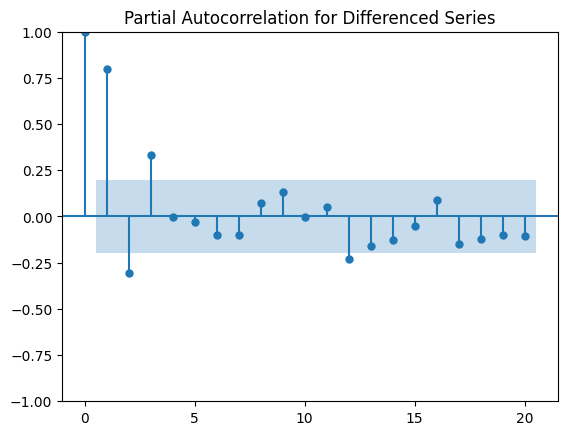

In [103]:
# YOUR CODE HERE
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(y_diff, lags=20, title='Partial Autocorrelation for Differenced Series');

We could choose `p = 3` as the first 3 lag terms seem above the significance level, but we could also go with a simpler model `p = 1`. 



### Step 3 - Build the model

Now that you have chosen the values for `p`, ` d`, and `q` for the ARIMA, 

👉 build the `arima_model` from `statsmodels`.
- fit the model
- print the model (`.summary`)

In [104]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(y, order=(1, 1, 2))

arima_result = arima_model.fit()

print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  100
Model:                 ARIMA(1, 1, 2)   Log Likelihood                -254.126
Date:                Thu, 20 Mar 2025   AIC                            516.253
Time:                        13:42:16   BIC                            526.633
Sample:                             0   HQIC                           520.453
                                - 100                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6976      0.130      5.365      0.000       0.443       0.952
ma.L1          0.4551      0.169      2.699      0.007       0.125       0.786
ma.L2         -0.0664      0.157     -0.424      0.6

☝️ If your p-values are too high, try to remove these terms by reducing the corresponding AR or SA coefficients.

You can evaluate the overall performance of your fit by minimizing the [`AIC - Akaike Information Criterion`](https://towardsdatascience.com/the-akaike-information-criterion-c20c8fd832f2) value

It seems that the (1,1,1) ARIMA models have less chance of overfitting (p-values remain low) and maintain a quasi-similar AIC score than other models

## 3. Evaluate model performance

👉 Visualize your model predictions with the `plot_predict()` method

- Look closely at the method default params, especially `dynamic` ones. 
- Do you think your model would have such a good performance in reality?

In [105]:
from statsmodels.graphics.tsaplots import plot_predict

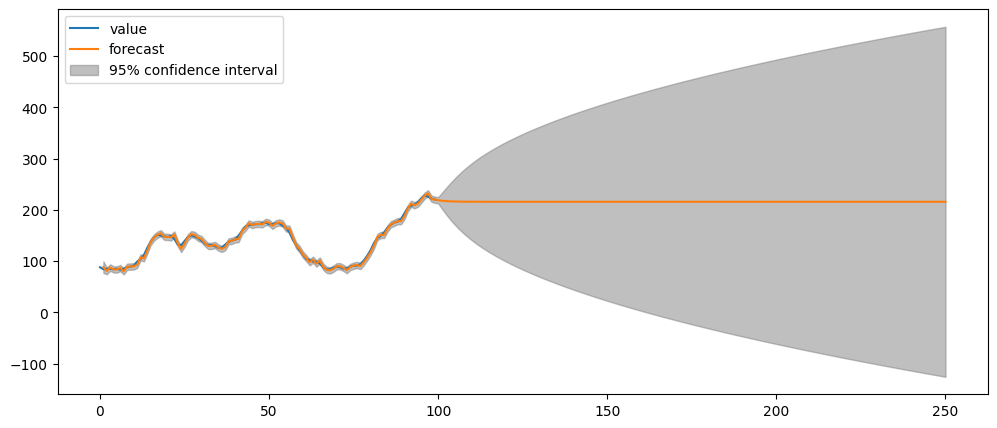

In [106]:
from statsmodels.graphics.tsaplots import plot_predict

fig, axs = plt.subplots(1, 1, figsize=(12, 5))
axs.plot(df['value'], label='value')
plot_predict(arima_result, start=1, end=250, ax=axs);

☝️ `dynamic=False` makes use of all available values `y` to predict `y_pred`, making your ARIMA prediction use up to $y_{t-1}$ to predict $y_t$. In reality, you don't have access to all `y`, especially if you want to predict several intervals in the future.

👉 Try to use `dynamic=True` to plot a prediction of the _last 15 values_ in a situation where the model only has _access to data up to 85_. That is to say, the model:
- predicts 86 based on true [1...85]
- then predicts 87 based on [1...85] _plus_ its previously predicted value for 86
- etc...iteratively until 100

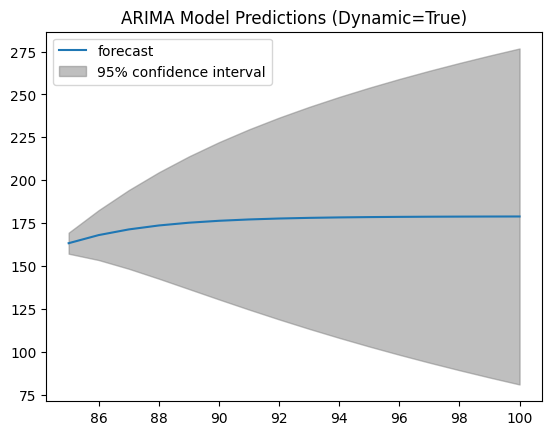

In [107]:
# YOUR CODE HERE
plot_predict(arima_result,start=85, end=100, dynamic=True)

plt.title('ARIMA Model Predictions (Dynamic=True)')
plt.show()

☝️ That's still not a _true_ forecast! Why?

<details>
    <summary>Answer</summary>

Our model has "seen" the whole `y_true` series during the fitting phase!
</details>

### 3.1 Out-of-Sample Forecasts (real "future")

👉 Create a train-test-split keep the last 15 data points only for the test set, and train your ARIMA on the train set only.

In [108]:
# YOUR CODE HERE
train_size = len(y) - 15
y_train = y[:train_size]
y_test = y[train_size:]

arima_model_train = ARIMA(y_train, order=(1, 1, 2))
arima_result_train = arima_model_train.fit()

print(arima_result_train.summary())

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                   85
Model:                 ARIMA(1, 1, 2)   Log Likelihood                -216.970
Date:                Thu, 20 Mar 2025   AIC                            441.939
Time:                        13:42:18   BIC                            451.662
Sample:                             0   HQIC                           445.848
                                 - 85                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7242      0.137      5.304      0.000       0.457       0.992
ma.L1          0.3901      0.175      2.233      0.026       0.048       0.732
ma.L2         -0.0907      0.161     -0.564      0.5

👉 We are "now" in step 85 and have never seen the future:
- Use the `get_forecast()` method on your fitted `arima` model to "forecast" the 15 next data points (i.e beyond the end of your train dataset) 

The method returns a `PredictionResultsWrapper` object from `statsmodels`.

**💻 Store this result in a variable named `forecast_results`.**  

It is hard to navigate at first, but here are some tips:
- You can find your forecasts in `forecast_results.predicted_mean`
- Your confidence intervals are given by `forecast_results.conf_int()`

In [109]:
# YOUR CODE HERE
forecast_results = arima_result_train.get_forecast(steps=15)

forecasted_values = forecast_results.predicted_mean

forecast_conf_int = forecast_results.conf_int()

print(forecasted_values)
print(forecast_conf_int)

85    163.126755
86    167.854337
87    171.278009
88    173.757401
89    175.552953
90    176.853276
91    177.794958
92    178.476916
93    178.970783
94    179.328437
95    179.587447
96    179.775020
97    179.910858
98    180.009231
99    180.080472
Name: predicted_mean, dtype: float64
    lower value  upper value
85   156.900943   169.352567
86   153.293168   182.415506
87   148.418248   194.137770
88   142.816333   204.698468
89   136.886108   214.219798
90   130.871580   222.834972
91   124.917268   230.672648
92   119.105588   237.848244
93   113.480289   244.461277
94   108.061167   250.595707
95   102.853360   256.321534
96    97.853263   261.696776
97    93.052290   266.769426
98    88.439255   271.579207
99    84.001861   276.159082


👉 Plot forecasted values as well as the higher and lower range of 95% uncertainty interval

👉 Try to also plot your previous 85 `y` real data points to better grasp model performance relative to the past

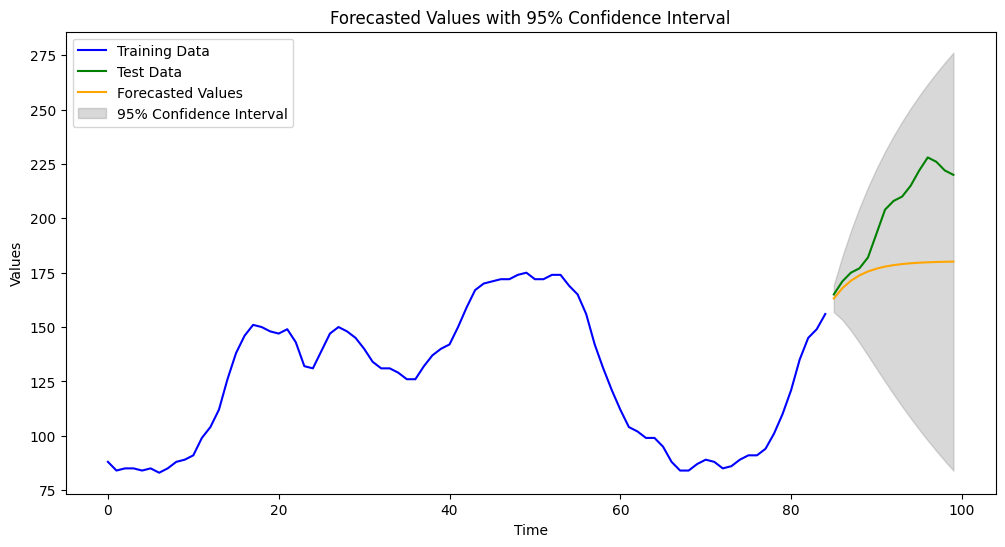

In [110]:
# YOUR CODE HERE
plt.figure(figsize=(12, 6))

plt.plot(y_train, label='Training Data', color='blue')

plt.plot(y_test, label='Test Data', color='green')

plt.plot(forecasted_values, label='Forecasted Values', color='orange')

plt.fill_between(
    forecast_conf_int.index,
    forecast_conf_int['lower value'],
    forecast_conf_int['upper value'],
    color='gray',
    alpha=0.3,
    label='95% Confidence Interval'
)

plt.title('Forecasted Values with 95% Confidence Interval')
plt.xlabel('Time')
plt.ylabel('Values')
plt.legend()
plt.show()

### 3.2 Can you trust your 95% confidence interval? (conditions for inference)

👉 Plot the residuals `model.resid` to ensure there are no patterns
- Normally distributed
- Mean zero
- Uniform variance
- No autoregressive patterns (you can plot_acf the residuals anyway if you want)

Note: residuals are constructed by 'seeing' all data as in `plot_predict(dynamic=False)`

Also, try to plot a histogram or KDE fit of the residuals to see if they are approximately normally distributed.

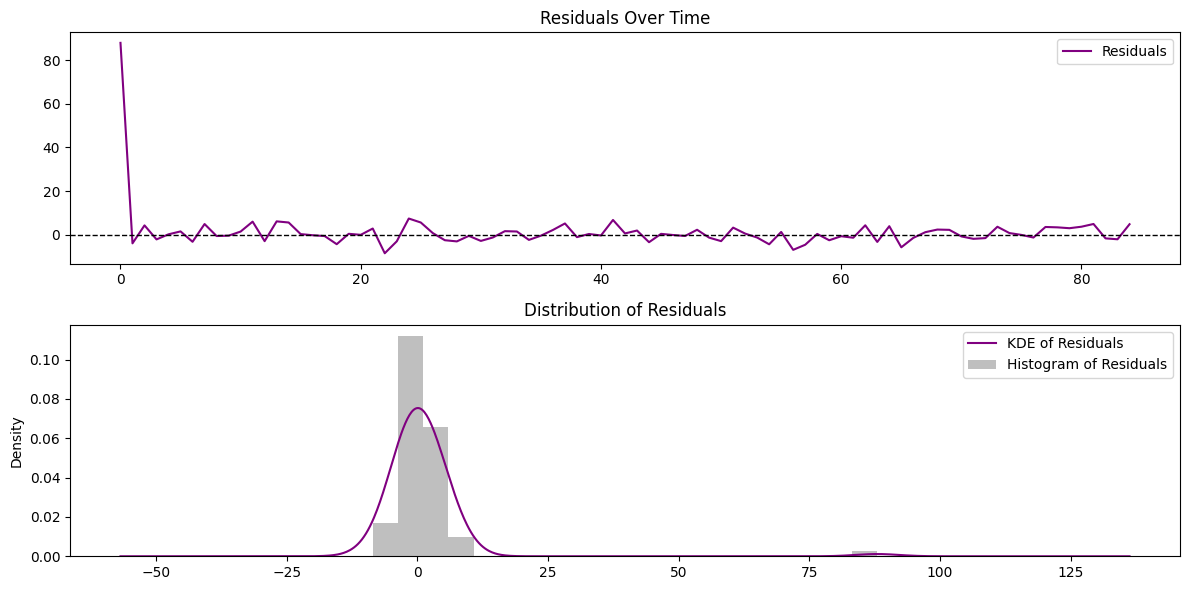

In [111]:
# YOUR CODE HERE
from statsmodels.graphics.tsaplots import plot_acf

residuals = arima_result_train.resid

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(residuals, label='Residuals', color='purple')
plt.axhline(0, linestyle='--', color='black', linewidth=1)
plt.title('Residuals Over Time')
plt.legend()

plt.subplot(2, 1, 2)
residuals.plot(kind='kde', color='purple', label='KDE of Residuals')
plt.hist(residuals, bins=20, density=True, alpha=0.5, color='gray', label='Histogram of Residuals')
plt.title('Distribution of Residuals')
plt.legend()

plt.tight_layout()
plt.show()


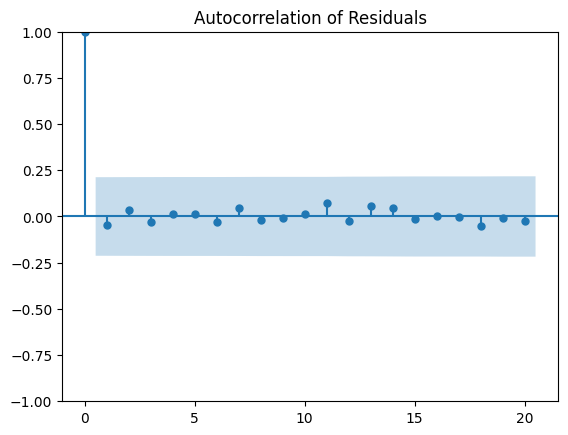

In [112]:
plot_acf(residuals, lags=20, title='Autocorrelation of Residuals');

## 3.3 Cross-validated performance metrics

👉 Below are the most common performance metrics for time series

In [113]:
import numpy as np
from statsmodels.tsa.stattools import acf

def forecast_accuracy(y_pred: pd.Series, y_true: pd.Series) -> float:

    mape = np.mean(np.abs(y_pred - y_true)/np.abs(y_true))  # Mean Absolute Percentage Error
    me = np.mean(y_pred - y_true)             # ME
    mae = np.mean(np.abs(y_pred - y_true))    # MAE
    mpe = np.mean((y_pred - y_true)/y_true)   # MPE
    rmse = np.mean((y_pred - y_true)**2)**.5  # RMSE
    corr = np.corrcoef(y_pred, y_true)[0,1]   # Correlation between the Actual and the Forecast
    mins = np.amin(np.hstack([y_pred.values.reshape(-1,1), y_true.values.reshape(-1,1)]), axis=1)
    maxs = np.amax(np.hstack([y_pred.values.reshape(-1,1), y_true.values.reshape(-1,1)]), axis=1)
    minmax = 1 - np.mean(mins/maxs)             # minmax
    acf1 = acf(y_pred-y_true, fft=False)[1]                      # Lag 1 Autocorrelation of Error

    forecast = ({
        'mape':mape,
        'me':me,
        'mae': mae,
        'mpe': mpe,
        'rmse':rmse,
        'acf1':acf1,
        'corr':corr,
        'minmax':minmax
    })

    return forecast

👉 Play with your ARIMA hyper-parameters and see the impact on your forecast performance

In [114]:
# YOUR CODE HERE
new_arima_model = ARIMA(y_train, order=(2, 1, 1))  # Adjust p, d, q values here
new_arima_result = new_arima_model.fit()

print(new_arima_result.summary())

new_forecast_results = new_arima_result.get_forecast(steps=15)
new_forecasted_values = new_forecast_results.predicted_mean
new_forecast_conf_int = new_forecast_results.conf_int()


                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                   85
Model:                 ARIMA(2, 1, 1)   Log Likelihood                -217.026
Date:                Thu, 20 Mar 2025   AIC                            442.052
Time:                        13:42:18   BIC                            451.775
Sample:                             0   HQIC                           445.960
                                 - 85                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6158      0.246      2.503      0.012       0.134       1.098
ar.L2          0.0446      0.224      0.199      0.842      -0.395       0.484
ma.L1          0.5187      0.211      2.460      0.0

/home/alrash/.pyenv/versions/lewagon/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


## 4 Grid Search

Try to run a Grid Search for (p,d,q) using `pmdarima`. Use at least
- `test='adf'`
- `trace=True`
- `error_action='ignore'`
- `suppress_warnings=True`

In [115]:
import pmdarima as pm

model = pm.auto_arima(
    y_train,
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    d=None,           # let model determine 'd'
    test='adf',       # using adf test to find optimal 'd'
    trace=True, error_action='ignore',  suppress_warnings=True
)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=449.662, Time=0.02 sec
 ARIMA(1,2,0)(0,0,0)[0]             : AIC=449.569, Time=0.02 sec
 ARIMA(0,2,1)(0,0,0)[0]             : AIC=445.819, Time=0.02 sec
 ARIMA(1,2,1)(0,0,0)[0]             : AIC=445.820, Time=0.03 sec
 ARIMA(0,2,2)(0,0,0)[0]             : AIC=441.300, Time=0.02 sec
 ARIMA(1,2,2)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(0,2,3)(0,0,0)[0]             : AIC=438.613, Time=0.03 sec
 ARIMA(1,2,3)(0,0,0)[0]             : AIC=440.036, Time=0.06 sec
 ARIMA(0,2,3)(0,0,0)[0] intercept   : AIC=440.231, Time=0.05 sec

Best model:  ARIMA(0,2,3)(0,0,0)[0]          
Total fit time: 0.390 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   85
Model:               SARIMAX(0, 2, 3)   Log Likelihood                -215.307
Date:                Thu, 20 Mar 2025   AIC                   

## (Optional) Cross-validate the Performance of your Model

In practice, results and Grid Search should always be cross-validated: 

Feel free to use [`sklearn.TimeSeriesSplit`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html) to create contiguous K-folds to truly evaluate the performance of your model and find the best hyperparams after cross-validation.

<img src='https://scikit-learn.org/stable/_images/sphx_glr_plot_cv_indices_013.png'>

**ARIMA - Cross-Validation using TimeSeriesSplit + Grid Search**

In [116]:
# YOUR CODE HERE
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd
import numpy as np

# Define the range of p, d, q values
p_values = range(0, 3)
d_values = range(0, 2)
q_values = range(0, 3)

# Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

# Store results
results = []

# Perform Grid Search with TimeSeriesSplit
for p in p_values:
    for d in d_values:
        for q in q_values:
            for train_index, test_index in tscv.split(y):
                y_train, y_test = y.iloc[train_index], y.iloc[test_index]
                try:
                    model = ARIMA(y_train, order=(p, d, q))
                    result = model.fit()
                    predictions = result.forecast(steps=len(y_test))
                    error = np.mean((predictions - y_test) ** 2)  # Mean Squared Error
                    results.append({'order': (p, d, q), 'error': error})
                except Exception as e:
                    continue

# Convert results to DataFrame
results_df = pd.DataFrame(results)


/home/alrash/.pyenv/versions/lewagon/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/alrash/.pyenv/versions/lewagon/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/alrash/.pyenv/versions/lewagon/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/alrash/.pyenv/versions/lewagon/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible sta

In [117]:
results_df.sort_values('error').groupby('order').mean()['error'].sort_values()

order
(2, 0, 2)    1613.972302
(1, 1, 0)    1644.886975
(0, 1, 0)    1679.187500
(1, 0, 2)    1701.946296
(0, 1, 1)    1709.126153
(1, 0, 0)    1709.612032
(1, 0, 1)    1715.852348
(2, 1, 2)    1720.094344
(1, 1, 1)    1726.761006
(2, 1, 1)    1736.596564
(1, 1, 2)    1759.228882
(2, 0, 0)    1764.644483
(0, 1, 2)    1773.162248
(2, 1, 0)    1800.113578
(2, 0, 1)    2037.489340
(0, 0, 2)    2077.796568
(0, 0, 1)    2129.236754
(0, 0, 0)    2198.620332
Name: error, dtype: float64

☝️ Our initial choice of model (1, 1, 2) is not so bad!
Notice that the dataset (100 data points) is in reality way too small to cross-validate anything!